In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Load dataset
df = pd.read_csv("student_performance_updated_1000.csv")

# Display a summary of missing values in each feature before cleaning
missing_table = df.isnull().sum().reset_index()
missing_table.columns = ["Feature", "MissingValues"]
print("Missing values per feature:")
print(missing_table)

Missing values per feature:
                      Feature  MissingValues
0                   StudentID             40
1                        Name             34
2                      Gender             48
3              AttendanceRate             40
4           StudyHoursPerWeek             50
5               PreviousGrade             33
6   ExtracurricularActivities             43
7             ParentalSupport             22
8                  FinalGrade             40
9                 Study Hours             24
10             Attendance (%)             41
11       Online Classes Taken             25


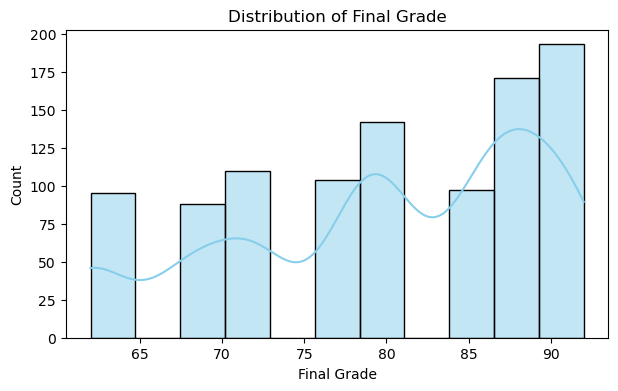

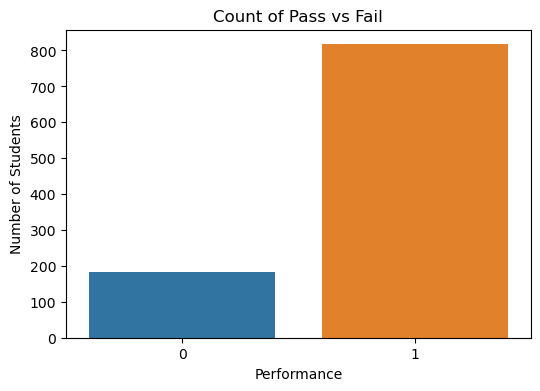

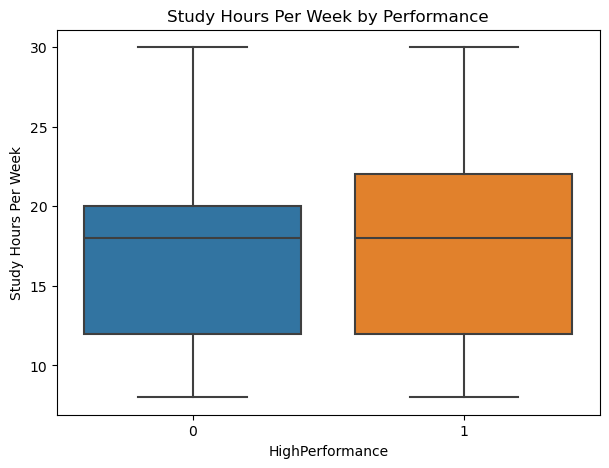

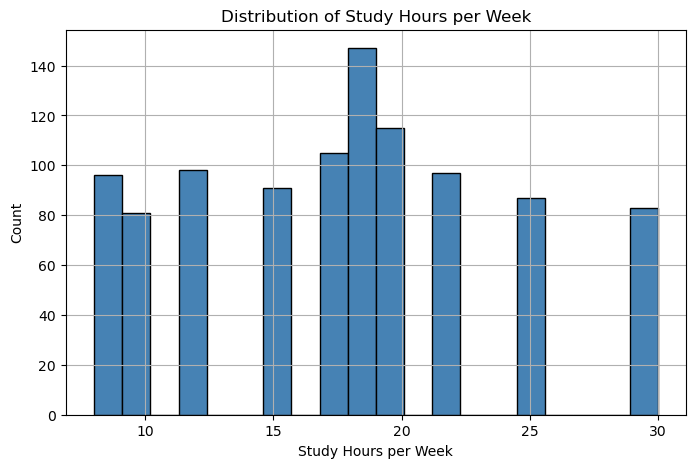

In [103]:
# Fill missing values
numerical_cols = ['AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade',
                  'ExtracurricularActivities', 'FinalGrade']  # include FinalGrade
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

categorical_cols = ['Gender', 'ParentalSupport', 'Online Classes Taken']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Drop unused columns
for col in ['Study Hours', 'Attendance (%)']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Create target label
df["HighPerformance"] = (df["FinalGrade"] >= 70).astype(int)

# Histogram of final grade
plt.figure(figsize=(7,4))
sns.histplot(df["FinalGrade"], kde=True, color='skyblue')
plt.title("Distribution of Final Grade")
plt.xlabel("Final Grade")
plt.ylabel("Count")
plt.show()

# Pass vs fail counts
plt.figure(figsize=(6,4))
sns.countplot(x="HighPerformance", data=df)
plt.title("Count of Pass vs Fail")
plt.xlabel("Performance")
plt.ylabel("Number of Students")
plt.show()

# Study hours by performance
plt.figure(figsize=(7,5))
sns.boxplot(x="HighPerformance", y="StudyHoursPerWeek", data=df)
plt.title("Study Hours Per Week by Performance")
plt.xlabel("HighPerformance")
plt.ylabel("Study Hours Per Week")
plt.show()

# Histogram of study hours
plt.figure(figsize=(8,5))
plt.hist(df["StudyHoursPerWeek"], bins=20, color='steelblue', edgecolor='black')
plt.title("Distribution of Study Hours per Week")
plt.xlabel("Study Hours per Week")
plt.ylabel("Count")
plt.grid(True)
plt.show()

                     Feature  Importance
1          StudyHoursPerWeek    0.262901
2              PreviousGrade    0.259451
0             AttendanceRate    0.232429
3  ExtracurricularActivities    0.125735
4                Gender_Male    0.047510
5        ParentalSupport_Low    0.036005
6     ParentalSupport_Medium    0.035969


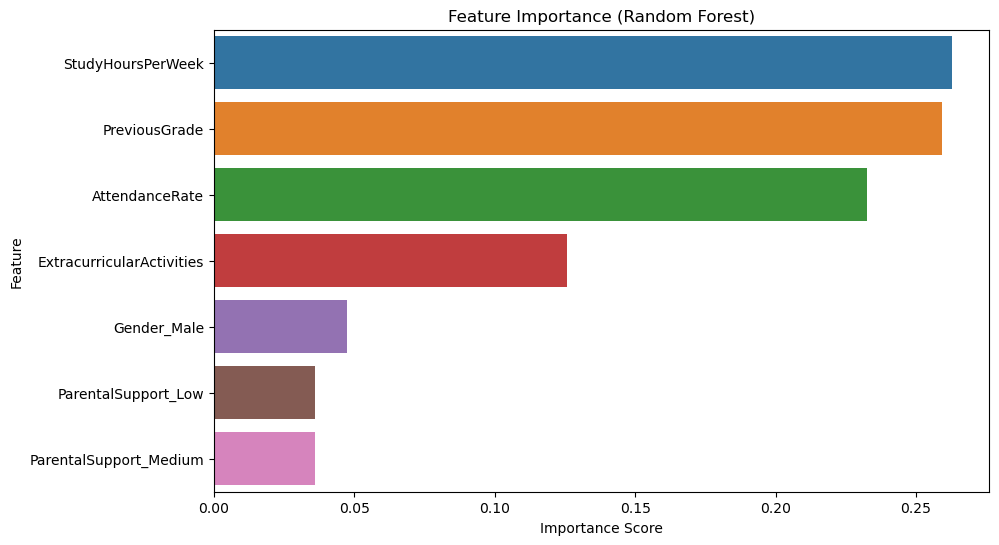

In [104]:
# Prepare features and target
X = df.drop(["HighPerformance", "FinalGrade", "StudentID", "Name"], axis=1)
y = df["HighPerformance"]

# Identify feature types
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first"), cat_features)
    ]
)

# Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf_model)
])

# Fit model
rf_pipeline.fit(X, y)

# Extract feature names after encoding
encoded_cat_features = rf_pipeline.named_steps['preprocess']\
                                  .named_transformers_['cat']\
                                  .get_feature_names_out(cat_features)

all_features = list(num_features) + list(encoded_cat_features)

# Get feature importance
importances = rf_pipeline.named_steps['model'].feature_importances_

# Create a DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [105]:
# Prepare features and target
X = df.drop(["HighPerformance", "FinalGrade", "StudentID", "Name"], axis=1)
y = df["HighPerformance"]

# Identify feature types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "Neural Network": MLPClassifier(max_iter=500)
}

results = {}

# Cross-validation
for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring="accuracy")
    results[name] = cv_scores.mean()

print("Cross-Validation Accuracy:")
for name, score in results.items():
    print(f"{name}: {score:.4f}")

# Hyperparameter tuning for Random Forest
param_grid = {
    "model__n_estimators": [50, 100, 150],
    "model__max_depth": [None, 5, 10]
}

rf_clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier())
])

rf_grid = GridSearchCV(rf_clf, param_grid, cv=5, scoring="accuracy")
rf_grid.fit(X_train, y_train)

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)
print(f"Best RF CV Accuracy: {rf_grid.best_score_:.4f}")

best_model_name = max(results, key=results.get)
print(f"\nBest Model Based on CV Accuracy: {best_model_name}")

Cross-Validation Accuracy:
Logistic Regression: 0.8175
Decision Tree: 0.6838
Random Forest: 0.8075
SVM: 0.8175
Neural Network: 0.8075

Best Random Forest Parameters:
{'model__max_depth': 10, 'model__n_estimators': 100}
Best RF CV Accuracy: 0.8187

Best Model Based on CV Accuracy: Logistic Regression


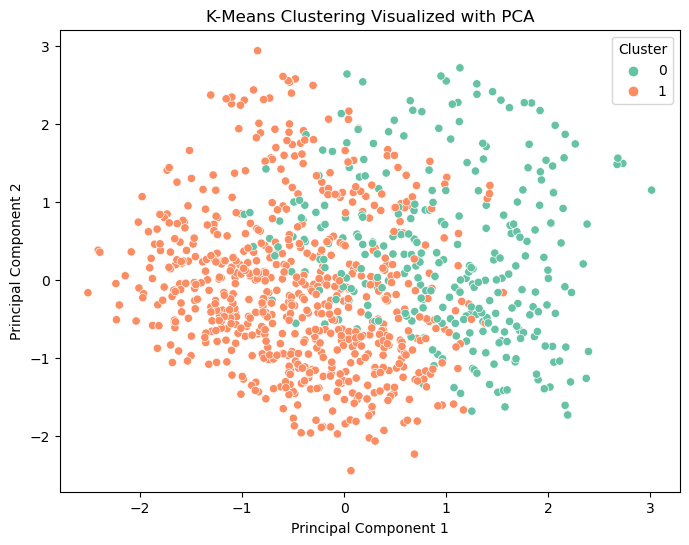

Explained Variance Ratio: [0.22858052 0.21717031]


In [106]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Apply preprocessing to prepare data for PCA and clustering
X_processed = preprocessor.fit_transform(X)

# Convert sparse matrix to dense if needed
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

# PCA reduction to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_processed)

# Create DataFrame for PCA visualization
df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clusters
})

# PCA cluster scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="Cluster", palette="Set2")
plt.title("K-Means Clustering Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

# Display explained variance of PCA components
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Evaluation Results Table:


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.815,0.815000,1.000000,0.898072,0.474382
Decision Tree,0.680,0.807453,0.797546,0.802469,0.480352
Random Forest,0.800,0.818653,0.969325,0.887640,0.456641
SVM,0.815,0.815000,1.000000,0.898072,0.421489
Neural Network,0.815,0.818182,0.993865,0.897507,0.443708



Best model based on F1-score: Logistic Regression


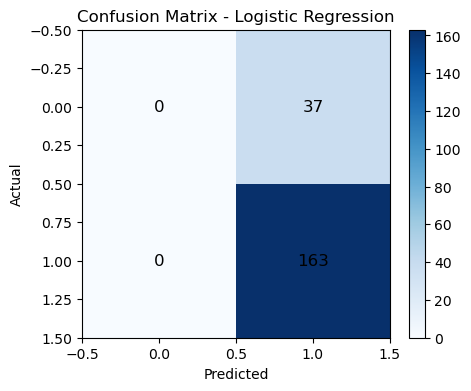

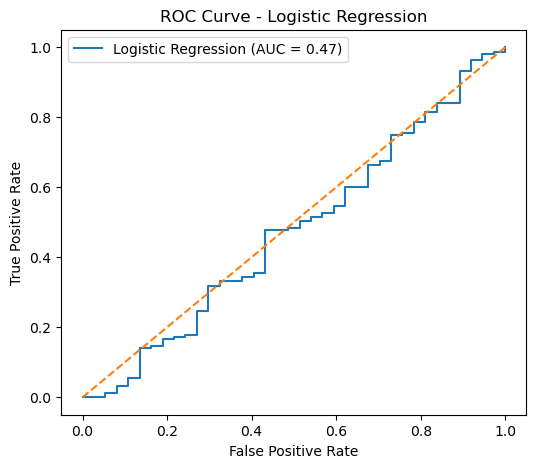

In [109]:
# Dictionary to store evaluation metrics for each model
eval_results = {}

# Dictionary to store the fitted pipelines
trained_clfs = {}

for name, model in models.items():
    # Pipeline: preprocessing + model
    clf = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    # Fit the pipeline
    clf.fit(X_train, y_train)
    trained_clfs[name] = clf
    
    # Predict on test set
    y_pred = clf.predict(X_test)
    
    # Scores for ROC-AUC
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, "decision_function"):
        y_proba = clf.decision_function(X_test)
    else:
        y_proba = y_pred
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        auc = float("nan")
    
    # Save metrics
    eval_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": auc
    }

# Results table
results_df = pd.DataFrame(eval_results).T
results_df = results_df[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]]

print("Evaluation Results Table:")
display(results_df)

# Best model by F1-score
best_model_name = max(eval_results, key=lambda m: eval_results[m]["F1-score"])
print(f"\nBest model based on F1-score: {best_model_name}")

best_clf = trained_clfs[best_model_name]

# Predictions of the best model
best_pred = best_clf.predict(X_test)

# Scores for ROC / ROC-AUC
if hasattr(best_clf, "predict_proba"):
    best_proba = best_clf.predict_proba(X_test)[:, 1]
elif hasattr(best_clf, "decision_function"):
    best_proba = best_clf.decision_function(X_test)
else:
    best_proba = best_pred

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Write values inside the matrix
for (i, j), z in np.ndenumerate(cm):
    plt.text(j, i, str(z), ha='center', va='center', color='black', fontsize=12)

plt.colorbar()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, best_proba)
auc_best = roc_auc_score(y_test, best_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {auc_best:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()